In [6]:
import sys
from pathlib import Path

# Add project root to sys.path
project_root = Path().resolve().parent
sys.path.append(str(project_root))

In [7]:
from functions.utils import *

import matplotlib.pyplot as plt

import pickle

In [8]:
FLIGHT_CONTEXTS = ["CRUISE", "TAKEOFF", "CLIMB1", "CLIMB2"] 


SENSOR_SHORT_NAMES = ["HPC_Tin", "LPT_Tin", "HPC_Pout_st"]


INDICATORS_TO_ESTIMATE = [
    "deg_CmpFan_s_mapWc_in",   # Fan mass flow
    "deg_CmpH_s_mapEff_in",    # HPC efficiency
    "deg_TrbH_s_mapEff_in",    # HPT efficiency
]


#--------------------------------------------------------------------------------------------------------------
NOISE_COV_PATH = "./data/noise_covariances.pkl"

# Sensor order in noise covariance matrices (6x6)
NOISE_SENSOR_ORDER = ["HP_Nmech", "HPC_Tout", "HPC_Tin", "LPT_Tin", "Fuel_flow", "HPC_Pout_st"]

NOISE_COV_MAP = {
    "CRUISE": "Cruise_noise_covariance",
    "TAKEOFF": "Takeoff_noise_covariance",
    "CLIMB1": "Climb1_noise_covariance",
    "CLIMB2": "Climb2_noise_covariance",
}



ALL_CONTEXTS = ["CRUISE",  "TAKEOFF", "CLIMB1", "CLIMB2"]
ALL_SENSORS = ["HPC_Tin", "LPT_Tin", "HPC_Pout_st"]


## 1.Generate with LHS 

In [25]:
df_synthetic = generate_multicontext_synthetic_data_lhs(
    n_samples=100,
    flight_contexts=FLIGHT_CONTEXTS,
    sensor_short_names=SENSOR_SHORT_NAMES,
    seed=42
)


print("\nSample of synthetic data:")
display_cols = ['sample_id'] + INDICATORS_TO_ESTIMATE[:2]
for ctx in FLIGHT_CONTEXTS[:2]:
    display_cols.append(f'{ctx}_DECKSMR{SENSOR_SHORT_NAMES[0]}')
print(df_synthetic[display_cols].head())


df_synthetic.to_csv("./data/synthetic_data.csv")

  Generated 20/100 samples
  Generated 40/100 samples
  Generated 60/100 samples
  Generated 80/100 samples
  Generated 100/100 samples

✓ Generated 100 consistent multi-context samples

Sample of synthetic data:
   sample_id  deg_CmpFan_s_mapWc_in  deg_CmpH_s_mapEff_in  \
0          0              -0.020158             -0.047547   
1          1               0.017342             -0.030722   
2          2              -0.049114             -0.048889   
3          3              -0.016696             -0.031235   
4          4              -0.037450             -0.007916   

   CRUISE_DECKSMRHPC_Tin  TAKEOFF_DECKSMRHPC_Tin  
0             344.207358              392.344026  
1             336.915682              391.633121  
2             347.335679              389.508081  
3             341.479824              390.889761  
4             344.575697              389.643387  


In [13]:
df_synthetic

,sample_id,deg_CmpBst_s_mapEff_in,deg_CmpBst_s_mapWc_in,deg_CmpFan_s_mapEff_in,deg_CmpFan_s_mapWc_in,deg_CmpH_s_mapEff_in,deg_CmpH_s_mapWc_in,deg_TrbH_s_mapEff_in,deg_TrbH_s_mapWc_in,deg_TrbL_s_mapEff_in,...,CLIMB1_ALT,CLIMB1_MACH,CLIMB1_COMMAND,CLIMB2_DECKSMRHPC_Tin,CLIMB2_DECKSMRLPT_Tin,CLIMB2_DECKSMRHPC_Pout_st,CLIMB2_DTAMB,CLIMB2_ALT,CLIMB2_MACH,CLIMB2_COMMAND
0,0,-0.030387,0.001649,-0.048429,-0.020158,-0.047547,-0.028380,-0.020381,-0.043786,-0.026064,...,15000,0.55,120000,344.397920,1212.40849,1453134.61,10.0,35000,0.78,120000
1,1,-0.031185,0.025259,-0.038822,0.017342,-0.030722,0.016218,-0.030777,-0.018064,-0.019414,...,15000,0.55,120000,343.039933,1264.85236,1558941.81,10.0,35000,0.78,120000
2,2,-0.002379,-0.027884,-0.044485,-0.049114,-0.048889,-0.016556,-0.046233,0.048956,-0.035077,...,15000,0.55,120000,342.139655,1205.32790,1196709.17,10.0,35000,0.78,120000
3,3,-0.005872,0.023626,-0.045663,-0.016696,-0.031235,0.013048,-0.029565,-0.035476,-0.049613,...,15000,0.55,120000,342.968301,1213.63600,1498522.98,10.0,35000,0.78,120000
4,4,-0.004719,-0.004266,-0.047350,-0.037450,-0.007916,0.005356,-0.042194,-0.048288,-0.041841,...,15000,0.55,120000,342.019341,1174.63079,1413266.94,10.0,35000,0.78,120000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,95,-0.003765,0.005801,-0.012622,0.016271,-0.045970,0.026890,-0.041889,0.021482,-0.043745,...,15000,0.55,120000,339.066205,1285.82782,1470560.91,10.0,35000,0.78,120000
96,96,-0.032268,-0.023148,-0.019066,-0.045301,-0.004976,0.018414,-0.025477,-0.015164,-0.015277,...,15000,0.55,120000,341.150250,1105.69917,1335276.29,10.0,35000,0.78,120000
97,97,-0.019127,0.021176,-0.015559,-0.021133,-0.020661,-0.033687,-0.014733,-0.011400,-0.011766,...,15000,0.55,120000,346.401200,1158.65161,1366117.01,10.0,35000,0.78,120000
98,98,-0.017494,-0.029055,-0.047871,-0.022375,-0.022576,-0.006737,-0.044171,0.009950,-0.024171,...,15000,0.55,120000,341.627292,1239.65590,1303865.84,10.0,35000,0.78,120000


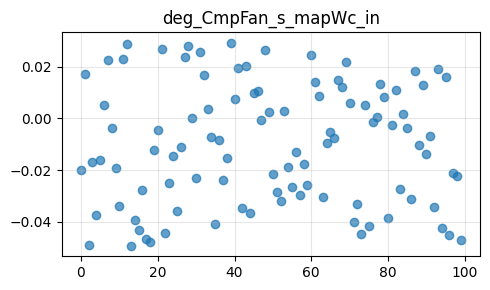

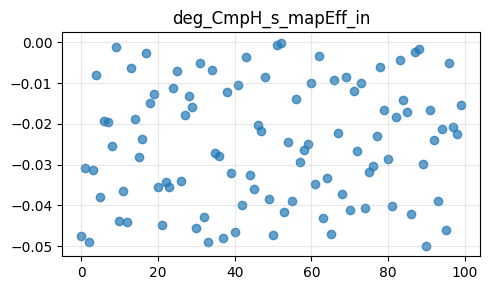

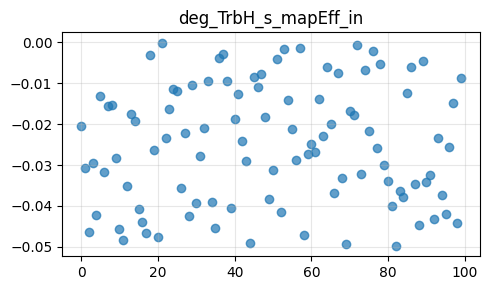

In [20]:
scatter_each_column (df_synthetic)

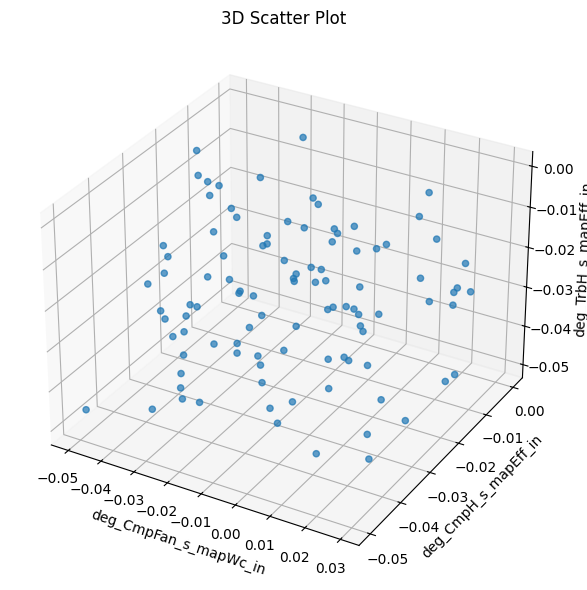

In [68]:
plot_3d_first_three(df_synthetic, INDICATORS_TO_ESTIMATE)


## 2.plot trajectory

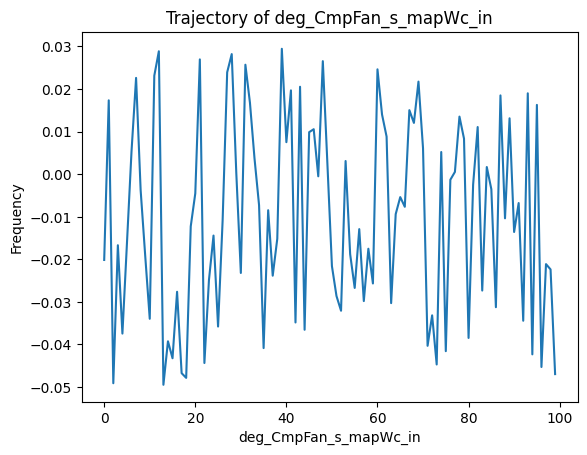

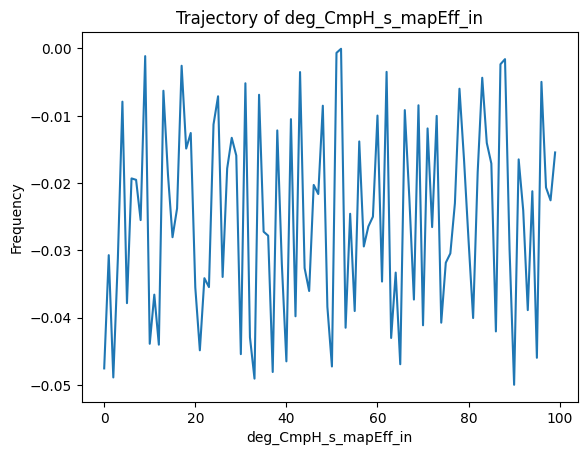

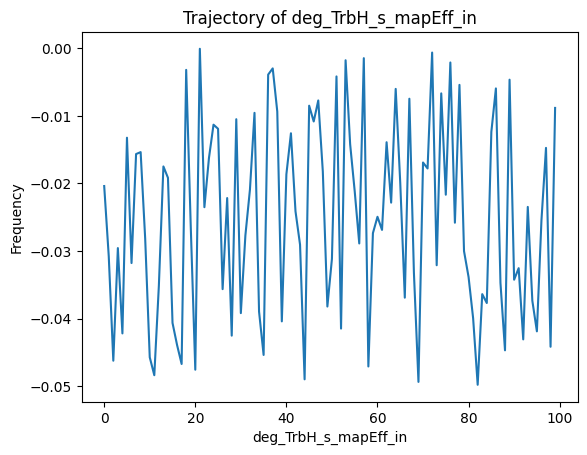

In [72]:
## plot trajectory

numeric_cols1 = df_synthetic.columns

for col in INDICATORS_TO_ESTIMATE:
 plt.figure()
 df_synthetic[col].plot()
 plt.title(f"Trajectory of {col}")
 plt.xlabel(col)
 plt.ylabel("Frequency")
 plt.show()

## 3.Generate with random uniform

It is also possible to run the random uniform version



  Generated 20/100 samples
  Generated 40/100 samples
  Generated 60/100 samples
  Generated 80/100 samples
  Generated 100/100 samples

✓ Generated 100 consistent multi-context samples

Sample of synthetic data:
   sample_id  deg_CmpFan_s_mapWc_in  deg_CmpH_s_mapEff_in  \
0          0              -0.002107             -0.042199   
1          1              -0.033013             -0.040909   
2          2              -0.020691             -0.027197   
3          3               0.025911             -0.001718   
4          4               0.022746             -0.037061   

   CRUISE_DECKSMRHPC_Tin  TAKEOFF_DECKSMRHPC_Tin  
0             344.543445              395.215589  
1             356.616085              399.484115  
2             341.988959              389.413135  
3             328.662702              384.024882  
4             335.448251              391.235810  


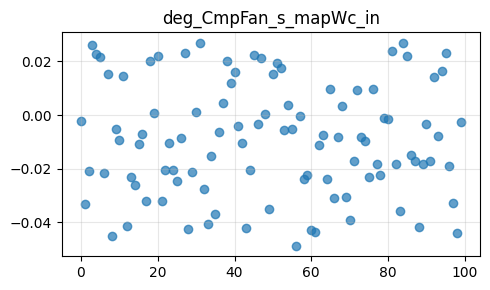

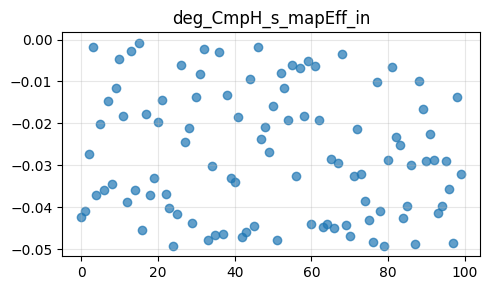

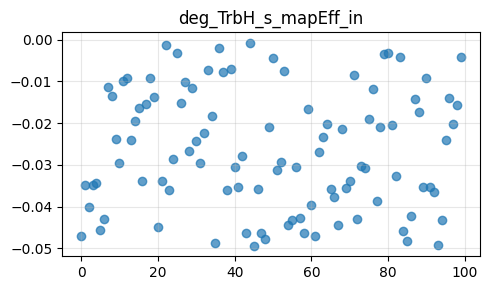

In [22]:
df_synthetic = generate_multicontext_synthetic_data_ru(
    n_samples=100,
    flight_contexts=FLIGHT_CONTEXTS,
    sensor_short_names=SENSOR_SHORT_NAMES,
    seed=42
)


print("\nSample of synthetic data:")
display_cols = ['sample_id'] + INDICATORS_TO_ESTIMATE[:2]
for ctx in FLIGHT_CONTEXTS[:2]:
    display_cols.append(f'{ctx}_DECKSMR{SENSOR_SHORT_NAMES[0]}')
print(df_synthetic[display_cols].head())


scatter_each_column (df_synthetic)

## 4.Add Noise to to sensor measurements

In [34]:
# Load noise covariances
with open(NOISE_COV_PATH, 'rb') as f:
    NOISE_COVARIANCES = pickle.load(f)
    

print("Noise covariances loaded:")
for ctx, key in NOISE_COV_MAP.items():
    cov = NOISE_COVARIANCES[key]
    std_devs = np.sqrt(np.diag(cov))
    print(f"  {ctx}: std_devs = {std_devs}")

    

Noise covariances loaded:
  CRUISE: std_devs = [1.20e-01 3.60e+00 5.00e-02 4.60e-01 2.16e-04 4.00e+02]
  TAKEOFF: std_devs = [2.0e-01 3.3e+00 5.0e-02 6.0e-01 7.8e-04 1.0e+03]
  CLIMB1: std_devs = [2.0e-01 3.3e+00 5.0e-02 6.0e-01 7.8e-04 1.0e+03]
  CLIMB2: std_devs = [2.0e-01 3.3e+00 5.0e-02 6.0e-01 7.8e-04 1.0e+03]


In [33]:
NOISE_COV_MAP

{'CRUISE': 'Cruise_noise_covariance',
 'TAKEOFF': 'Takeoff_noise_covariance',
 'CLIMB1': 'Climb1_noise_covariance',
 'CLIMB2': 'Climb2_noise_covariance'}

In [9]:
CLEAN_DATA_PATH = "../data/synthetic_data.csv"
# Load clean data
df_clean = pd.read_csv(CLEAN_DATA_PATH)
print(f"Loaded {len(df_clean)} rows from {CLEAN_DATA_PATH}")

Loaded 100 rows from ../data/synthetic_data.csv


In [60]:
# Generate noisy version of data

df_noisy = add_noise_to_data(df_clean, ALL_CONTEXTS, ALL_SENSORS, seed=123)

# Save noisy data
noisy_data_path = CLEAN_DATA_PATH.replace('.csv', '_noisy.csv')
df_noisy.to_csv(noisy_data_path, index=False)
print(f"Noisy data saved to: {noisy_data_path}")

# Show noise effect
print("\nNoise effect sample (row 0, CRUISE):")
for s in ALL_SENSORS:
    col = f'CRUISE_DECKSMR{s}'
    clean_val = df_clean.loc[0, col]
    noisy_val = df_noisy.loc[0, col]
    diff = noisy_val - clean_val
    print(f"  {s}: clean={clean_val:.4f}, noisy={noisy_val:.4f}, noise={diff:.4f}")

Noisy data saved to: ./data/synthetic_data_noisy.csv

Noise effect sample (row 0, CRUISE):
  HPC_Tin: clean=344.2074, noisy=344.1784, noise=-0.0289
  LPT_Tin: clean=1210.1083, noisy=1210.2385, noise=0.1302
  HPC_Pout_st: clean=1447792.0600, noisy=1447357.8078, noise=-434.2522


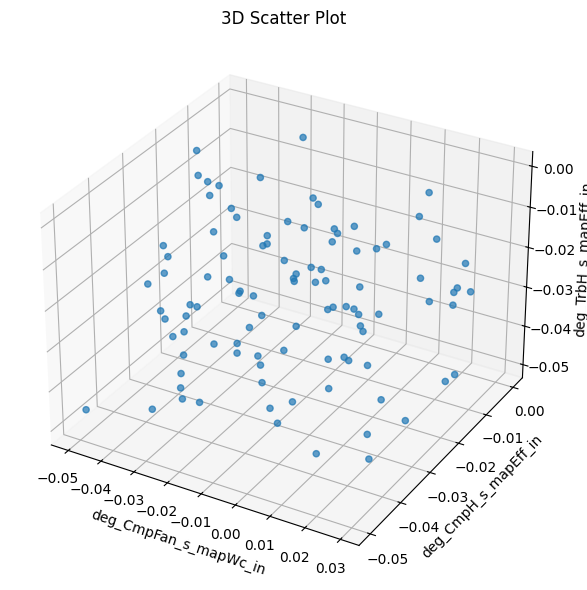

In [63]:
plot_3d_first_three(df_noisy, INDICATORS_TO_ESTIMATE)

# This is done with already generated data

Let us check which context has more noise

In [11]:
CLEAN_DATA_PATH = "../data/synthetic_data.csv"
# Load clean data
df_clean = pd.read_csv(CLEAN_DATA_PATH)
print(f"Loaded {len(df_clean)} rows from {CLEAN_DATA_PATH}")


noisy_data_path =  "../data/synthetic_data_noisy.csv"

# Load clean data
df_noisy = pd.read_csv(noisy_data_path )
print(f"Loaded {len(df_noisy)} rows from {noisy_data_path }")

Loaded 100 rows from ../data/synthetic_data.csv
Loaded 100 rows from ../data/synthetic_data_noisy.csv


In [12]:
# Show noise effect
print("\nNoise effect sample (row 0, CRUISE):")
for s in ALL_SENSORS:
    col = f'CRUISE_DECKSMR{s}'
    clean_val = df_clean.loc[0, col]
    noisy_val = df_noisy.loc[0, col]
    diff = noisy_val - clean_val
    print(f"  {s}: clean={clean_val:.4f}, noisy={noisy_val:.4f}, noise={diff:.4f}")


Noise effect sample (row 0, CRUISE):
  HPC_Tin: clean=344.2074, noisy=344.1784, noise=-0.0289
  LPT_Tin: clean=1210.1083, noisy=1210.2385, noise=0.1302
  HPC_Pout_st: clean=1447792.0600, noisy=1447357.8078, noise=-434.2522


In [13]:
def print_noise_sample(df_clean, df_noisy, row_idx, context, sensors):
    print(f"\nNoise effect sample (row {row_idx}, {context}):")
    for s in sensors:
        col = f'{context}_DECKSMR{s}'
        clean_val = df_clean.loc[row_idx, col]
        noisy_val = df_noisy.loc[row_idx, col]
        diff = noisy_val - clean_val
        print(f"  {s:<15} clean={clean_val:.4f}  noisy={noisy_val:.4f}  noise={diff:+.4f}")


print_noise_sample(df_clean, df_noisy, row_idx=0, context="CRUISE", sensors=ALL_SENSORS)



Noise effect sample (row 0, CRUISE):
  HPC_Tin         clean=344.2074  noisy=344.1784  noise=-0.0289
  LPT_Tin         clean=1210.1083  noisy=1210.2385  noise=+0.1302
  HPC_Pout_st     clean=1447792.0600  noisy=1447357.8078  noise=-434.2522


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def plot_noise_by_context(df_clean, df_noisy, contexts, sensors):
    noise_data = []

    for ctx in contexts:
        for s in sensors:
            col = f'{ctx}_DECKSMR{s}'
            noise = df_noisy[col] - df_clean[col]
            for v in noise.values:
                noise_data.append({
                    "context": ctx,
                    "sensor": s,
                    "noise": v
                })

    noise_df = pd.DataFrame(noise_data)

    plt.figure(figsize=(10, 5))
    noise_df.boxplot(column="noise", by="context", grid=True)
    plt.title("Noise Distribution per Context")
    plt.suptitle("")
    plt.ylabel("Noise (noisy − clean)")
    plt.xlabel("Flight context")
    plt.tight_layout()
    plt.show()

    return noise_df


<Figure size 1000x500 with 0 Axes>

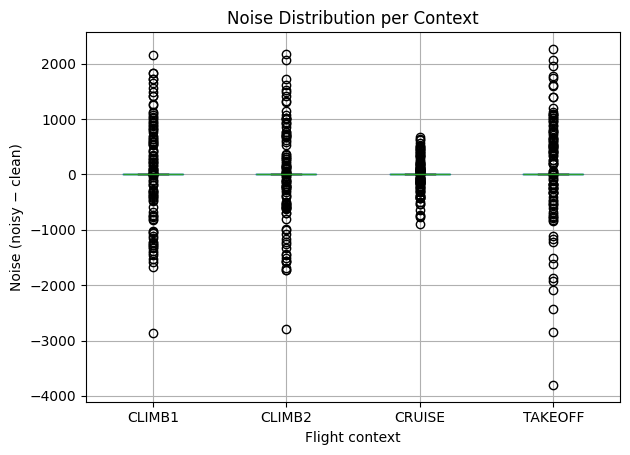

In [17]:
noisy_df = plot_noise_by_context(
    df_clean,
    df_noisy,
    contexts=["CRUISE", "TAKEOFF", "CLIMB1", "CLIMB2"],
    sensors=ALL_SENSORS
)


In [18]:
noisy_df

,context,sensor,noise
0,CRUISE,HPC_Tin,-0.028930
1,CRUISE,HPC_Tin,-0.007003
2,CRUISE,HPC_Tin,0.087186
3,CRUISE,HPC_Tin,-0.020168
4,CRUISE,HPC_Tin,0.032103
...,...,...,...
1195,CLIMB2,HPC_Pout_st,-47.011254
1196,CLIMB2,HPC_Pout_st,-1251.184940
1197,CLIMB2,HPC_Pout_st,341.754568
1198,CLIMB2,HPC_Pout_st,201.334438


---
The plot shows there is less noise at the CRUISE level.
---

In [21]:
import seaborn as sns

def plot_noise_heatmap(df_clean, df_noisy, contexts, sensors):
    heatmap_data = []

    for ctx in contexts:
        for s in sensors:
            col = f'{ctx}_DECKSMR{s}'
            mean_abs_noise = np.mean(np.abs(df_noisy[col] - df_clean[col]))
            heatmap_data.append({
                "context": ctx,
                "sensor": s,
                "mean_abs_noise": mean_abs_noise
            })

    hm_df = pd.DataFrame(heatmap_data)
    pivot = hm_df.pivot(index="sensor", columns="context", values="mean_abs_noise")

    plt.figure(figsize=(10, 6))
    sns.heatmap(pivot, annot=True, fmt=".2e", cmap="Reds")
    plt.title("Mean Absolute Noise per Sensor and Context")
    plt.tight_layout()
    plt.show()

    return hm_df


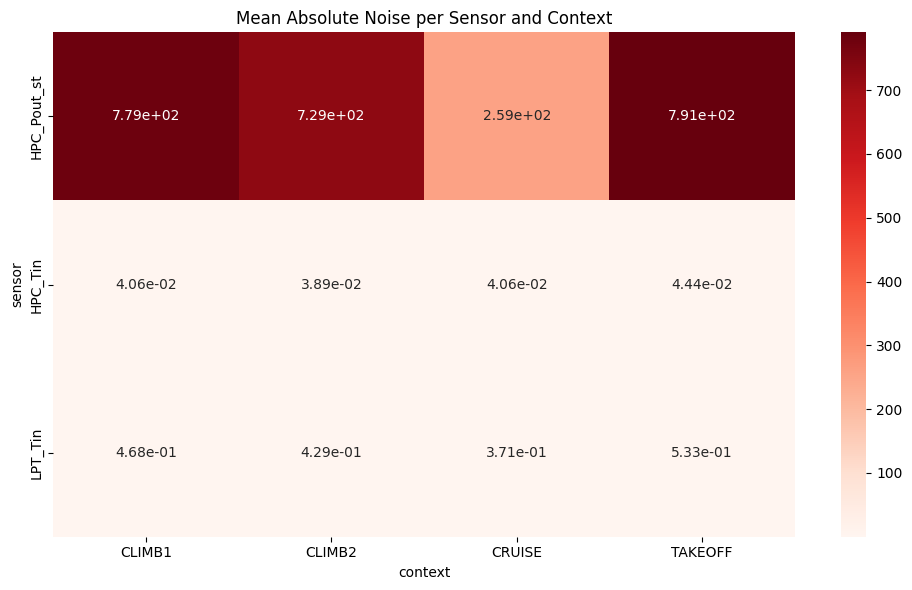

In [22]:
hm_df = plot_noise_heatmap(
    df_clean,
    df_noisy,
    contexts=["CRUISE", "TAKEOFF", "CLIMB1", "CLIMB2"],
    sensors=ALL_SENSORS
)

In [23]:
hm_df

,context,sensor,mean_abs_noise
0,CRUISE,HPC_Tin,0.040570
1,CRUISE,LPT_Tin,0.370904
2,CRUISE,HPC_Pout_st,259.388700
3,TAKEOFF,HPC_Tin,0.044406
4,TAKEOFF,LPT_Tin,0.533291
5,TAKEOFF,HPC_Pout_st,790.710502
6,CLIMB1,HPC_Tin,0.040634
7,CLIMB1,LPT_Tin,0.467870
8,CLIMB1,HPC_Pout_st,778.591429
9,CLIMB2,HPC_Tin,0.038946
